<a href="https://colab.research.google.com/github/adityasaicareer/pytorch/blob/master/tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/lits-png")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/lits-png


In [2]:
path

'/kaggle/input/lits-png'

In [3]:
import torch
from torch import nn
import torchvision
from torchvision import transforms

In [4]:
from torch.utils.data import Dataset,DataLoader

In [5]:
!pip install opencv-python

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import cv2

In [7]:
imageroot=glob.glob(path+'/dataset_6/dataset_6/*volume*')
imageroot.sort()

In [8]:
len(imageroot)

58638

In [9]:
segmentation=glob.glob(path+'/dataset_6/dataset_6/*lesion*')

In [10]:
len(segmentation)

58638

In [11]:
segmentation.sort()

In [12]:
imageroot[:4]

['/kaggle/input/lits-png/dataset_6/dataset_6/volume-0_0.png',
 '/kaggle/input/lits-png/dataset_6/dataset_6/volume-0_1.png',
 '/kaggle/input/lits-png/dataset_6/dataset_6/volume-0_10.png',
 '/kaggle/input/lits-png/dataset_6/dataset_6/volume-0_11.png']

In [13]:
segmentation[:4]

['/kaggle/input/lits-png/dataset_6/dataset_6/segmentation-0_lesionmask_0.png',
 '/kaggle/input/lits-png/dataset_6/dataset_6/segmentation-0_lesionmask_1.png',
 '/kaggle/input/lits-png/dataset_6/dataset_6/segmentation-0_lesionmask_10.png',
 '/kaggle/input/lits-png/dataset_6/dataset_6/segmentation-0_lesionmask_11.png']

In [14]:
tfms=transforms.Compose(
    [
        transforms.ToTensor(),

        transforms.ConvertImageDtype(torch.float)
    ]
)

In [15]:
class opendataset(Dataset):
  def __init__(self,imageroot,maskroot):
    self.images=imageroot
    self.masks=maskroot
  def __len__(self):
    return len(self.images)
  def __getitem__(self,ix):
    imagepath=self.images[ix]
    maskpath=self.masks[ix]
    image=cv2.imread(imagepath)
    image=tfms(image)
    image=image/255
    mask=cv2.imread(maskpath,0)

    mask=torch.tensor(mask)
    mask=mask.long()
    # print(image.shape)
    # print(mask.shape)
    return image.to('cuda'),mask.to('cuda')


In [16]:
dataset=opendataset(imageroot,segmentation)

In [17]:
dataset[0]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0'),
 tensor([[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0, 

In [18]:
from torchvision.models import vgg16_bn

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
train_imageroot,test_imageroot=train_test_split(imageroot,test_size=0.2,random_state=42)


In [21]:
train_segmentation,test_segmentation=train_test_split(segmentation,test_size=0.2,random_state=42)

In [22]:
train_dataset=opendataset(train_imageroot[:5000],train_segmentation[:5000])
test_dataset=opendataset(test_imageroot,test_segmentation)

In [23]:
train_loader=DataLoader(train_dataset,batch_size=2,shuffle=True)

In [24]:
test_loader=DataLoader(test_dataset,batch_size=2,shuffle=True)

In [25]:
def conv(in_channels,out_channels):
  return nn.Sequential(
      nn.Conv2d(in_channels,out_channels,stride=1,kernel_size=3,padding=1),
      nn.BatchNorm2d(out_channels),
      nn.ReLU(inplace=True)
  )

In [26]:
def upconv(in_channels,out_channels):
  return nn.Sequential(
      nn.ConvTranspose2d(in_channels,out_channels,kernel_size=2,stride=2),
      nn.ReLU(inplace=True)
  )

In [27]:
class Unet(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder=vgg16_bn(pretrained=True).features
    self.block1=nn.Sequential(*self.encoder[:6])
    self.block2=nn.Sequential(*self.encoder[6:13])
    self.block3=nn.Sequential(*self.encoder[13:20])
    self.block4=nn.Sequential(*self.encoder[20:27])
    self.block5=nn.Sequential(*self.encoder[27:34])
    self.bottleneck=nn.Sequential(*self.encoder[34:])

    self.bottleconv=conv(512,1024)
    self.upconv6=upconv(1024,512)
    self.conv6=conv(512+512,512)
    self.upconv7=upconv(512,256)
    self.conv7=conv(256+512,256)
    self.upconv8=upconv(256,128)
    self.conv8=conv(128+256,128)
    self.upconv9=upconv(128,64)
    self.conv9=conv(64+128,64)
    self.upconv10=upconv(64,32)
    self.conv10=conv(32+64,32)
    self.conv11=nn.Conv2d(32,12,kernel_size=1)

  def forward(self,x):
    block1=self.block1(x)
    block2=self.block2(block1)
    block3=self.block3(block2)
    block4=self.block4(block3)
    block5=self.block5(block4)
    bottleneck=self.bottleneck(block5)
    bottleconv=self.bottleconv(bottleneck)
    x=self.upconv6(bottleconv)
    x=torch.cat([x,block5],dim=1)
    x=self.conv6(x)
    x=self.upconv7(x)
    x=torch.cat([x,block4],dim=1)
    x=self.conv7(x)
    x=self.upconv8(x)
    x=torch.cat([x,block3],dim=1)
    x=self.conv8(x)
    x=self.upconv9(x)
    x=torch.cat([x,block2],dim=1)
    x=self.conv9(x)
    x=self.upconv10(x)
    x=torch.cat([x,block1],dim=1)
    x=self.conv10(x)
    x=self.conv11(x)
    return x

In [28]:
model=Unet().to('cuda')

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth
100%|██████████| 528M/528M [00:02<00:00, 221MB/s]


In [29]:
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

In [30]:
unetloss=nn.CrossEntropyLoss()

In [31]:
def train_batch(model,inputs,optimizer):
  model.train()
  image,mask=inputs
  preds=model(image)
  loss=unetloss(preds,mask)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  return loss.item()


In [32]:
for i in range(50):
  batchloss=0
  for ex,inputs in enumerate(train_loader):
    loss=train_batch(model,inputs,optimizer)
    batchloss+=loss
    print(f'the batch. : {ex} loss :{loss}')
  print(batchloss)

Streaming output truncated to the last 5000 lines.
the batch. : 2 loss :0.0002873361518140882
the batch. : 3 loss :3.083956244154251e-06
the batch. : 4 loss :2.638751993799815e-06
the batch. : 5 loss :2.8063855097570922e-06
the batch. : 6 loss :0.000907645677216351
the batch. : 7 loss :0.0019422605400905013
the batch. : 8 loss :5.417570355348289e-05
the batch. : 9 loss :0.008253151550889015
the batch. : 10 loss :0.0030858798418194056
the batch. : 11 loss :7.443396725648199e-07
the batch. : 12 loss :6.749374961145804e-07
the batch. : 13 loss :1.6103967936942354e-07
the batch. : 14 loss :0.0005361602525226772
the batch. : 15 loss :1.2873814512204262e-06
the batch. : 16 loss :6.055149128769699e-07
the batch. : 17 loss :0.0009018593700602651
the batch. : 18 loss :0.0031282587442547083
the batch. : 19 loss :8.770119848122704e-07
the batch. : 20 loss :1.062037881638389e-05
the batch. : 21 loss :7.693965926591773e-07
the batch. : 22 loss :0.0004889085539616644
the batch. : 23 loss :3.21545962

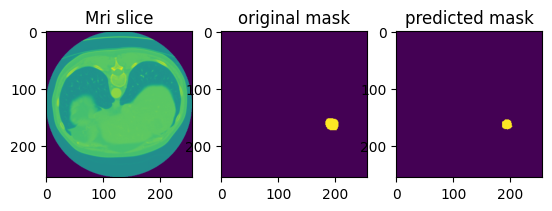

In [140]:
im, mask = next(iter(test_loader))
_mask = model(im.float().to('cuda'))
_, _mask = torch.max(_mask, dim=1)


plt.subplot(1,3,1)

plt.imshow(im[0].permute(1,2,0).detach().cpu()[:,:,0])

plt.title('Mri slice')

plt.subplot(1,3,2)
plt.imshow(mask.permute(1,2,0).detach().cpu()[:,:,0])
plt.title('original mask')


plt.subplot(1,3,3)

plt.title('predicted mask')
plt.imshow(_mask.permute(1,2,0).detach().cpu()[:,:,0])


In [136]:
torch.save(model.state_dict(),'tumor_detection.pth')